# Public Transport Demand Prediction — Leakage-Safe Version

**Important:** This version removes the old execution outputs and rebuilds the historical demand features using an actual hourly time grid. The previous `0.9679` R² should not be treated as the final result until this notebook is rerun from top to bottom.

Run all cells in order after uploading `processed_bus.csv`.

This cell was empty and has been removed for clarity.

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [130]:
df = pd.read_csv('processed_bus.csv')
df

,trip_id,timestamp,route_id,city,route_type,origin_station,dest_station,boarding_count,alighting_count,passenger_count,...,operates_night,is_electric,is_peak_hour,is_weekend,is_holiday,is_school_hours,is_night_service,anomaly_flag,anomaly_type,vehicle_type
0,TRIP_RT_LON_007_0006048,2020-09-09 00:00:00,RT_LON_007,London,bus,STN_LON_0209,STN_LON_0010,0,0,0,...,0,1,0,0,0,0,1,0,none,Normal Bus
1,TRIP_RT_TOK_001_0000099,2020-01-05 03:00:00,RT_TOK_001,Tokyo,bus,STN_TOK_0137,STN_TOK_0192,0,0,10,...,1,1,0,1,0,0,1,0,none,Double Decker
2,TRIP_RT_TOK_009_0005339,2020-08-10 11:00:00,RT_TOK_009,Tokyo,bus,STN_TOK_0045,STN_TOK_0214,2,2,51,...,0,1,0,0,0,1,0,0,none,Normal Bus
3,TRIP_RT_TOK_009_0005366,2020-08-11 14:00:00,RT_TOK_009,Tokyo,bus,STN_TOK_0045,STN_TOK_0214,3,3,53,...,0,1,0,0,0,1,0,0,none,Double Decker
4,TRIP_RT_TOK_009_0003069,2020-05-07 21:00:00,RT_TOK_009,Tokyo,bus,STN_TOK_0045,STN_TOK_0214,0,0,28,...,0,1,0,0,0,0,0,0,none,Normal Bus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,TRIP_RT_TOK_002_0006110,2020-09-11 14:00:00,RT_TOK_002,Tokyo,bus,STN_TOK_0042,STN_TOK_0038,2,2,24,...,0,0,0,0,0,1,0,0,none,Double Decker
99996,TRIP_RT_NEW_008_0005831,2020-08-30 23:00:00,RT_NEW_008,New_York,bus,STN_NEW_0018,STN_NEW_0127,0,0,55,...,0,0,0,1,0,0,1,0,none,Normal Bus
99997,TRIP_RT_TOK_009_0005373,2020-08-11 21:00:00,RT_TOK_009,Tokyo,bus,STN_TOK_0045,STN_TOK_0214,3,3,54,...,0,1,0,0,0,0,0,0,none,Double Decker
99998,TRIP_RT_TOK_003_0001756,2020-03-14 04:00:00,RT_TOK_003,Tokyo,bus,STN_TOK_0079,STN_TOK_0006,0,0,67,...,0,0,0,1,0,0,1,0,none,Normal Bus


This cell was empty and has been removed for clarity.

**2. SELECT RELEVANT COLUMNS**

In [131]:
columns_to_keep = [
    'timestamp',
    'route_id',
    'origin_station',
    'dest_station',
    'passenger_count',
    'weather_condition',
    'temperature_c',
    'headway_min',
    'vehicle_capacity',
    'is_peak_hour',
    'is_weekend',
    'is_holiday',
    'is_school_hours',
    'is_night_service'
]

df = df[columns_to_keep]

print("Shape after column selection:", df.shape)
df.shape

Shape after column selection: (100000, 14)


(100000, 14)

**3. DATA CLEANING**


3.1 Dataset Information

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          100000 non-null  object 
 1   route_id           100000 non-null  object 
 2   origin_station     100000 non-null  object 
 3   dest_station       100000 non-null  object 
 4   passenger_count    100000 non-null  int64  
 5   weather_condition  100000 non-null  object 
 6   temperature_c      100000 non-null  float64
 7   headway_min        100000 non-null  int64  
 8   vehicle_capacity   100000 non-null  int64  
 9   is_peak_hour       100000 non-null  int64  
 10  is_weekend         100000 non-null  int64  
 11  is_holiday         100000 non-null  int64  
 12  is_school_hours    100000 non-null  int64  
 13  is_night_service   100000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 10.7+ MB


3.2 Missing Value Analysis

In [133]:
df.isnull().sum()

,0
timestamp,0
route_id,0
origin_station,0
dest_station,0
passenger_count,0
weather_condition,0
temperature_c,0
headway_min,0
vehicle_capacity,0
is_peak_hour,0


In [134]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

timestamp            0.0
route_id             0.0
origin_station       0.0
dest_station         0.0
passenger_count      0.0
weather_condition    0.0
temperature_c        0.0
headway_min          0.0
vehicle_capacity     0.0
is_peak_hour         0.0
is_weekend           0.0
is_holiday           0.0
is_school_hours      0.0
is_night_service     0.0
dtype: float64


3.3 Duplicate Record Analysis

In [135]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [136]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (100000, 14)


3.4 Timestamp Conversion

In [137]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
print(df['timestamp'])

0       2020-09-09 00:00:00
1       2020-01-05 03:00:00
2       2020-08-10 11:00:00
3       2020-08-11 14:00:00
4       2020-05-07 21:00:00
                ...        
99995   2020-09-11 14:00:00
99996   2020-08-30 23:00:00
99997   2020-08-11 21:00:00
99998   2020-03-14 04:00:00
99999   2020-12-30 19:00:00
Name: timestamp, Length: 100000, dtype: datetime64[ns]


In [138]:
print("Invalid timestamps:", df['timestamp'].isnull().sum())

Invalid timestamps: 0


In [139]:
df = df.dropna(subset=['timestamp'])

In [140]:
numeric_columns = [
    'passenger_count',
    'temperature_c',
    'headway_min',
    'vehicle_capacity'
]

df[numeric_columns].describe()

,passenger_count,temperature_c,headway_min,vehicle_capacity
count,100000.000000,100000.000000,100000.000000,100000.00000
mean,25.199580,14.989820,12.602710,90.00000
std,26.461589,7.681726,3.667106,30.00015
min,0.000000,-6.590000,6.000000,60.00000
25%,0.000000,8.410000,10.000000,60.00000
50%,17.000000,14.940000,14.000000,90.00000
75%,48.000000,21.600000,15.000000,120.00000
max,80.000000,36.540000,19.000000,120.00000


In [141]:
print(df['passenger_count'].describe())

count    100000.000000
mean         25.199580
std          26.461589
min           0.000000
25%           0.000000
50%          17.000000
75%          48.000000
max          80.000000
Name: passenger_count, dtype: float64


In [142]:
print("Zero passenger counts:",
      (df['passenger_count'] == 0).sum())

Zero passenger counts: 36805


In [143]:
print("Negative passenger counts:",
      (df['passenger_count'] < 0).sum())

Negative passenger counts: 0


In [144]:
df = df[df['passenger_count'] >= 0]

In [145]:
df[['passenger_count']].describe()

,passenger_count
count,100000.000000
mean,25.199580
std,26.461589
min,0.000000
25%,0.000000
50%,17.000000
75%,48.000000
max,80.000000


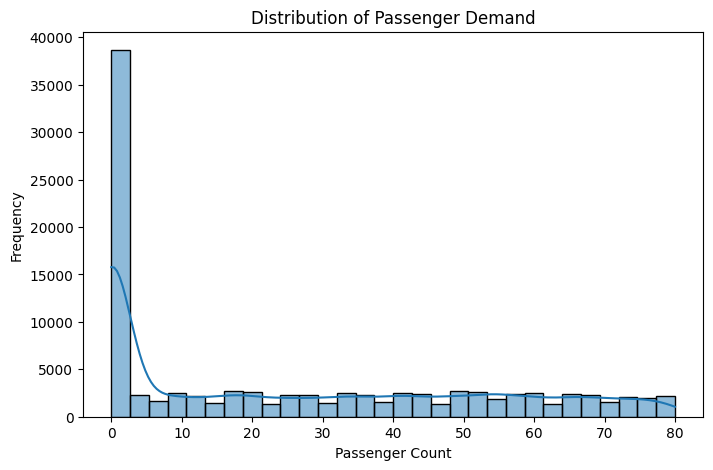

In [146]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['passenger_count'],
    bins=30,
    kde=True
)

plt.title('Distribution of Passenger Demand')
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')

plt.show()

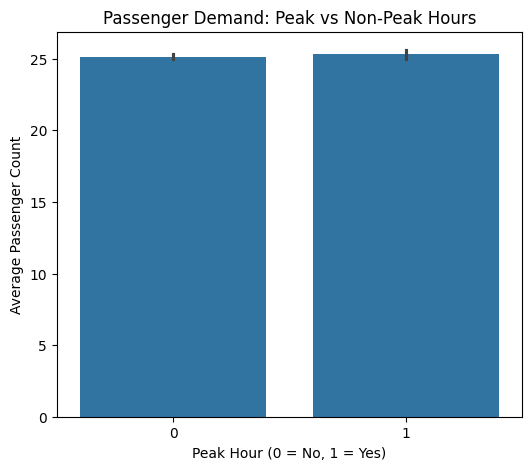

In [147]:
plt.figure(figsize=(6, 5))

sns.barplot(
    data=df,
    x='is_peak_hour',
    y='passenger_count'
)

plt.title('Passenger Demand: Peak vs Non-Peak Hours')
plt.xlabel('Peak Hour (0 = No, 1 = Yes)')
plt.ylabel('Average Passenger Count')

plt.show()

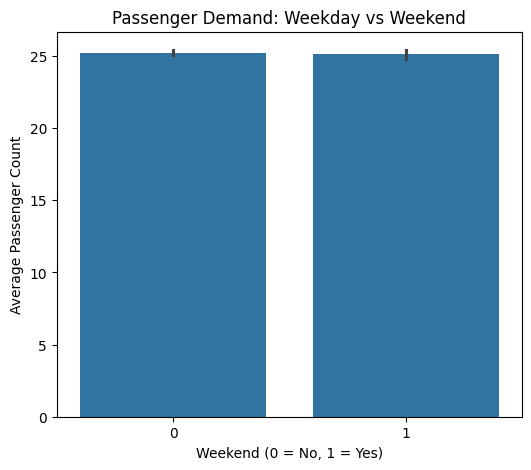

In [148]:
plt.figure(figsize=(6, 5))

sns.barplot(
    data=df,
    x='is_weekend',
    y='passenger_count'
)

plt.title('Passenger Demand: Weekday vs Weekend')
plt.xlabel('Weekend (0 = No, 1 = Yes)')
plt.ylabel('Average Passenger Count')

plt.show()

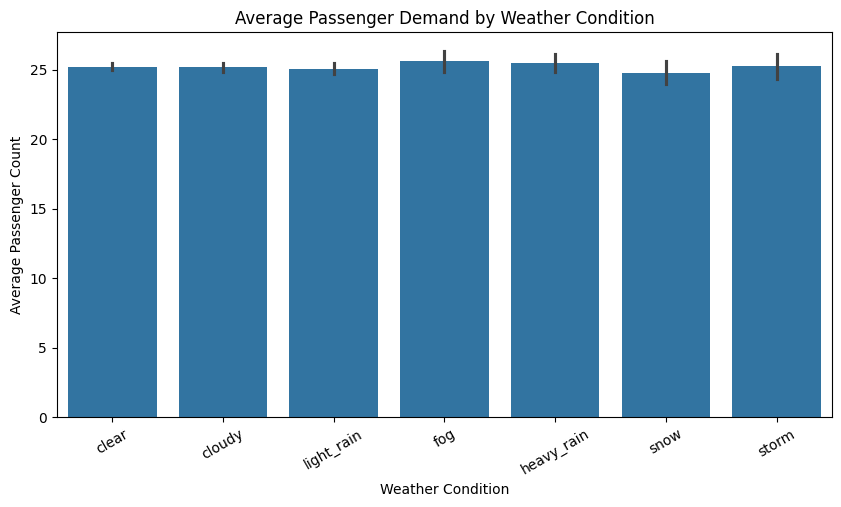

In [149]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x='weather_condition',
    y='passenger_count'
)

plt.title('Average Passenger Demand by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Passenger Count')
plt.xticks(rotation=30)

plt.show()

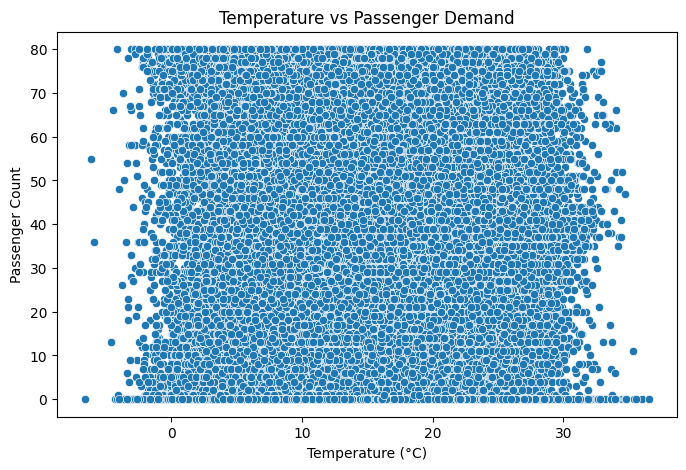

In [150]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='temperature_c',
    y='passenger_count'
)

plt.title('Temperature vs Passenger Demand')
plt.xlabel('Temperature (°C)')
plt.ylabel('Passenger Count')

plt.show()

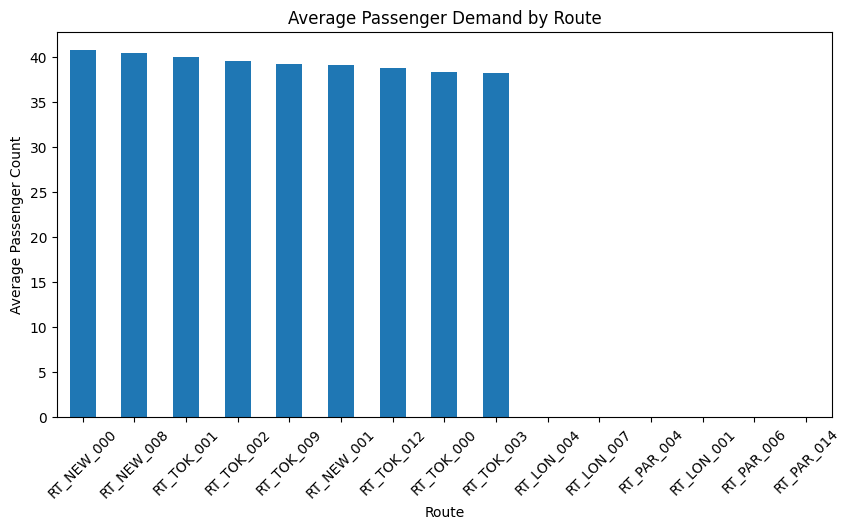

In [151]:
route_demand = (
    df.groupby('route_id')['passenger_count']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

route_demand.plot(kind='bar')

plt.title('Average Passenger Demand by Route')
plt.xlabel('Route')
plt.ylabel('Average Passenger Count')

plt.xticks(rotation=45)
plt.show()

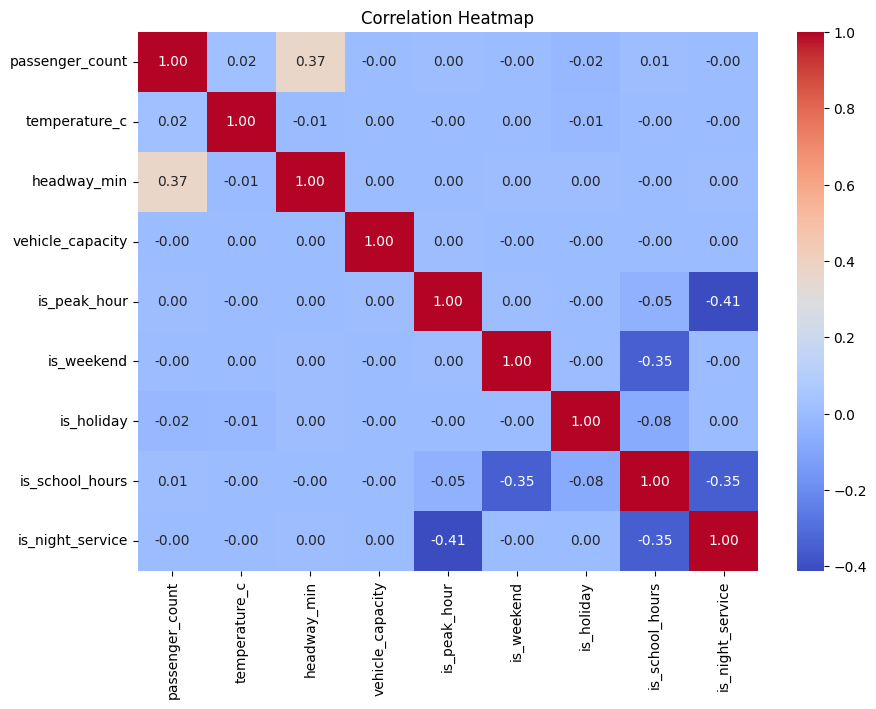

In [152]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [153]:
df = df.sort_values(["route_id", "timestamp"]).copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Keep one observation per route/timestamp. If duplicates exist, aggregate
# numeric demand by mean and retain the first available contextual values.
duplicate_count = df.duplicated(["route_id", "timestamp"]).sum()
print("Duplicate route/timestamp rows before aggregation:", duplicate_count)

if duplicate_count:
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    agg = {c: "mean" for c in numeric_cols if c != "route_id"}
    for c in df.columns:
        if c not in agg and c not in ["route_id", "timestamp"]:
            agg[c] = "first"
    df = df.groupby(["route_id", "timestamp"], as_index=False).agg(agg)

# Re-create time/calendar features after timestamp normalization.
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["day_of_year"] = df["timestamp"].dt.dayofyear
df["week_of_year"] = df["timestamp"].dt.isocalendar().week.astype(int)
df["quarter"] = df["timestamp"].dt.quarter

# Create actual hourly grids independently for each route.
route_frames = []

for route_id, g in df.groupby("route_id", sort=False):
    g = g.sort_values("timestamp").set_index("timestamp")

    hourly = g.resample("1h").asfreq()

    # Route identity is constant.
    hourly["route_id"] = route_id

    # Demand and historical predictors must not be forward-filled:
    # doing so could manufacture target information.
    # Static/context fields may be forward-filled only within the route.
    static_cols = [
        c for c in [
            "origin_station", "dest_station", "weather_condition",
            "temperature_c", "headway_min", "vehicle_capacity",
            "is_peak_hour", "is_weekend", "is_holiday",
            "is_school_hours", "is_night_service"
        ] if c in hourly.columns
    ]

    for c in static_cols:
        hourly[c] = hourly[c].ffill()

    hourly["passenger_count"] = g["passenger_count"].resample("1h").mean()
    hourly["passenger_count"] = hourly["passenger_count"].fillna(0) # Fill NaN passenger counts with 0

    route_frames.append(hourly.reset_index())

df_hourly = pd.concat(route_frames, ignore_index=True)
df_hourly = df_hourly.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

# Historical demand features use only strictly earlier hours.
grp = df_hourly.groupby("route_id")["passenger_count"]

# Generate all potential lag and rolling mean features
all_lags = [1, 2, 3, 24]
all_rolling_windows = [3, 6, 24, 168] # Add 168h rolling mean

for lag in all_lags:
    df_hourly[f"passenger_count_lag_{lag}h"] = grp.shift(lag)

for window in all_rolling_windows:
    df_hourly[f"rolling_mean_{window}h"] = (
        grp.transform(
            lambda s: s.shift(1).rolling(window=window, min_periods=1).mean() # Changed min_periods to 1
        )
    )

# Define the specific historical columns we want to keep for the model
desired_historical_cols = ["rolling_mean_168h"]

# Identify all generated historical column names
all_generated_historical_feature_names = \
    [f"passenger_count_lag_{lag}h" for lag in all_lags] + \
    [f"rolling_mean_{window}h" for window in all_rolling_windows]

# Identify which of these generated columns are NOT desired
columns_to_drop_from_df_hourly = [
    col for col in all_generated_historical_feature_names
    if col not in desired_historical_cols
]

# Drop the undesired historical columns from df_hourly
df_hourly = df_hourly.drop(columns=columns_to_drop_from_df_hourly, errors='ignore')

# Now, set historical_cols to refer only to the features that are kept
historical_cols = desired_historical_cols

# Only rows with a real target and complete historical information are eligible
# for supervised learning.
df_final_features = df_hourly.dropna(
    subset=["passenger_count"] + historical_cols
).copy()

print("Rows after hourly alignment and leakage-safe features:", len(df_final_features))
print("Feature columns:", historical_cols)

display(
    df_final_features[
        ["timestamp", "route_id", "passenger_count"] + historical_cols
    ].head(10)
)


Duplicate route/timestamp rows before aggregation: 0
Rows after hourly alignment and leakage-safe features: 123299
Feature columns: ['rolling_mean_168h']


,timestamp,route_id,passenger_count,rolling_mean_168h
1,2020-01-01 01:00:00,RT_LON_001,0.0,0.0
2,2020-01-01 02:00:00,RT_LON_001,0.0,0.0
3,2020-01-01 03:00:00,RT_LON_001,0.0,0.0
4,2020-01-01 04:00:00,RT_LON_001,0.0,0.0
5,2020-01-01 05:00:00,RT_LON_001,0.0,0.0
6,2020-01-01 06:00:00,RT_LON_001,0.0,0.0
7,2020-01-01 07:00:00,RT_LON_001,0.0,0.0
8,2020-01-01 08:00:00,RT_LON_001,0.0,0.0
9,2020-01-01 09:00:00,RT_LON_001,0.0,0.0
10,2020-01-01 10:00:00,RT_LON_001,0.0,0.0


## 14. Data Splitting for Model Training

In [154]:
# Never use the target itself, timestamp as model inputs.
# Drop all historical features explicitly before dynamically re-adding the desired one.
X_all_features = df_final_features.drop(
    columns=[
        "passenger_count", "timestamp",
        "passenger_count_lag_24h", "rolling_mean_24h" # Explicitly remove if they somehow persist
    ],
    errors="ignore"
)
y_all_all_features = df_final_features["passenger_count"]

# Chronological holdout: earliest 80% for training, latest 20% for testing.
order = np.argsort(df_final_features["timestamp"].values)

X_all_features = X_all_features.iloc[order].reset_index(drop=True)
y_all_features = y_all_all_features.iloc[order].reset_index(drop=True)
ordered_times = df_final_features["timestamp"].iloc[order].reset_index(drop=True)

split_index_all_features = int(len(X_all_features) * 0.8)

X_train_all = X_all_features.iloc[:split_index_all_features].copy()
y_train_all = y_all_features.iloc[:split_index_all_features].copy()

X_test_all = X_all_features.iloc[split_index_all_features:].copy()
y_test_all = y_all_features.iloc[split_index_all_features:].copy()

print("Training data shape:", X_train_all.shape)
print("Testing data shape :", X_test_all.shape)
print("Train period:", ordered_times.iloc[0], "to",
      ordered_times.iloc[split_index_all_features - 1])
print("Test period :", ordered_times.iloc[split_index_all_features], "to",
      ordered_times.iloc[-1])
print("\nTarget in model features:", "passenger_count" in X_train_all.columns)
print("\nFeatures:")
print(X_train_all.columns.tolist())

# Update model_features and updated_numerical_features_all to reflect changes
global model_features
global updated_numerical_features_all
model_features = X_train_all.columns.tolist()

# Dynamically update numerical_features based on actual X_train_all columns, excluding categoricals
current_numerical_features = [f for f in model_features if f not in categorical_features]
updated_numerical_features_all = current_numerical_features


Training data shape: (98639, 20)
Testing data shape : (24660, 20)
Train period: 2020-01-01 01:00:00 to 2020-10-18 14:00:00
Test period : 2020-10-18 14:00:00 to 2020-12-30 23:00:00

Target in model features: False

Features:
['route_id', 'origin_station', 'dest_station', 'weather_condition', 'temperature_c', 'headway_min', 'vehicle_capacity', 'is_peak_hour', 'is_weekend', 'is_holiday', 'is_school_hours', 'is_night_service', 'hour', 'day_of_week', 'day', 'month', 'day_of_year', 'week_of_year', 'quarter', 'rolling_mean_168h']


## 15. Model Training and Evaluation

In [155]:
import xgboost as xgb

# Re-create the preprocessor with updated numerical features for all features
fast_preprocessor_all = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)

# Train the XGBoost pipeline directly with reasonable hyperparameters
xgb_model = Pipeline(
    steps=[
        ('preprocessor', fast_preprocessor_all),
        ('model', xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            tree_method='hist',
            n_estimators=100,
            learning_rate=0.1,
            max_depth=7,
            subsample=0.9,
            colsample_bytree=0.9
        ))
    ]
)

print("Starting XGBoost model training...")
xgb_model.fit(X_train_all, y_train_all)
print("XGBoost model training finished.")

best_xgb_model = xgb_model # In this simplified flow, xgb_model is the best_xgb_model

# Evaluation on the untouched chronological test period
y_pred_xgb = best_xgb_model.predict(X_test_all)

mae_xgb = mean_absolute_error(y_test_all, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_all, y_pred_xgb))
r2_xgb = r2_score(y_test_all, y_pred_xgb)

print("\nXGBoost Results — Unseen Chronological Test Period")
print("----------------------------------------------------")
print(f"MAE : {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R²  : {r2_xgb:.4f}")

print("\nInterpretation:")
print("- This R² is the score on the final time-ordered holdout.")
print("- Historical demand features use only timestamps before each target.")

Starting XGBoost model training...
XGBoost model training finished.

XGBoost Results — Unseen Chronological Test Period
----------------------------------------------------
MAE : 7.1105
RMSE: 14.2164
R²  : 0.7777

Interpretation:
- This R² is the score on the final time-ordered holdout.
- Historical demand features use only timestamps before each target.


## 16. Save Model

In [156]:
import joblib
import os

model_path = 'public_transport_demand_model.pkl'
joblib.dump(best_xgb_model, model_path)
print(f"Model saved to {model_path}")

Model saved to public_transport_demand_model.pkl


## 17. Prediction and Recommendation Function

In [157]:
import math
import os
import joblib

# Load the persisted pipeline when this notebook is reopened.
# If 'best_xgb_model' is not defined (e.g., if previous cells were not run),
# load it from the saved file.
if 'best_xgb_model' not in globals():
    model_path = 'public_transport_demand_model.pkl'
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"{model_path} was not found. Run the training cells first to create it."
        )
    best_xgb_model = joblib.load(model_path)

# Reload raw_bus for the prediction function
raw_bus = pd.read_csv('processed_bus.csv')
raw_bus['timestamp'] = pd.to_datetime(raw_bus['timestamp'], errors='coerce')
raw_bus = raw_bus.dropna(subset=['timestamp', 'passenger_count']).copy()
raw_bus = raw_bus[raw_bus['passenger_count'] >= 0]
raw_bus = raw_bus.sort_values(['route_id', 'timestamp']).reset_index(drop=True)

# These are the features used by the saved XGBoost pipeline.
# model_features variable is already in the kernel state from previous execution

def predict_and_recommend(
    route_id,
    timestamp,
    origin_station=None,
    dest_station=None,
    weather_condition=None,
    temperature_c=None,
    headway_min=None,
    vehicle_capacity=None,
    safety_buffer=1.10,
    show_result=True
):
    """Predict passengers and recommend vehicles for one route and time."""
    prediction_time = pd.to_datetime(timestamp, errors='raise')
    route_rows = raw_bus[raw_bus['route_id'].eq(route_id)].copy()
    if route_rows.empty:
        raise ValueError(f"Unknown route_id: {route_id}")

    # Use only information available before the requested prediction time.
    history = route_rows[route_rows['timestamp'] < prediction_time]
    if history.empty:
        history = route_rows
    history = history.sort_values('timestamp')
    latest = history.iloc[-1]

    def latest_or_default(column, value):
        return latest[column] if value is None else value

    def route_median(column):
        value = pd.to_numeric(history[column], errors='coerce').median()
        if pd.isna(value):
            value = pd.to_numeric(raw_bus[column], errors='coerce').median()
        return float(value)

    # Reindex demand to an hourly time grid so rolling_mean_168h can be calculated correctly.
    demand = (
        history[["timestamp", "passenger_count"]]
        .drop_duplicates("timestamp")
        .set_index("timestamp")["passenger_count"]
        .resample("1h").mean()
    )

    # Historical information is allowed only before prediction_time.
    demand = demand.loc[demand.index < prediction_time]

    # Handle cases where there might not be enough historical data for 168h rolling mean
    roll_mean_168h = np.nan

    # This logic assumes 'demand' is an hourly resampled series
    if len(demand.dropna()) >= 1:
        end_roll = prediction_time - pd.Timedelta(hours=1)
        start_roll = prediction_time - pd.Timedelta(hours=168)
        roll_values = demand.loc[start_roll:end_roll].dropna()
        # If we have at least 1 observation in the window, calculate the mean
        if len(roll_values) >= 1:
            roll_mean_168h = float(roll_values.mean())

    # Fallback to route median if historical features are still NaN
    if pd.isna(roll_mean_168h):
        roll_mean_168h = route_median('passenger_count')

    hour = prediction_time.hour
    day_of_week = prediction_time.dayofweek
    is_weekend = int(day_of_week >= 5)
    is_peak_hour = int(hour in [7, 8, 9, 16, 17, 18, 19])
    is_school_hours = int(not is_weekend and 8 <= hour <= 15)
    is_night_service = int(hour < 6 or hour >= 22)

    input_row = pd.DataFrame([{
        'route_id': route_id,
        'origin_station': latest_or_default('origin_station', origin_station),
        'dest_station': latest_or_default('dest_station', dest_station),
        'weather_condition': latest_or_default('weather_condition', weather_condition),
        'temperature_c': route_median('temperature_c') if temperature_c is None else temperature_c,
        'headway_min': route_median('headway_min') if headway_min is None else headway_min,
        'vehicle_capacity': route_median('vehicle_capacity') if vehicle_capacity is None else vehicle_capacity,
        'is_peak_hour': is_peak_hour,
        'is_weekend': is_weekend,
        'is_holiday': 0, # Assuming no specific holiday info at prediction time for simplicity
        'is_school_hours': is_school_hours,
        'is_night_service': is_night_service,
        'hour': hour,
        'day_of_week': day_of_week,
        'day': prediction_time.day,
        'month': prediction_time.month,
        'day_of_year': prediction_time.dayofyear,
        'week_of_year': int(prediction_time.isocalendar().week),
        'quarter': prediction_time.quarter,
        'rolling_mean_168h': roll_mean_168h # New historical feature
    }], columns=model_features)

    predicted_passengers = max(0, float(best_xgb_model.predict(input_row)[0]))
    capacity = max(1, int(round(float(input_row['vehicle_capacity'].iloc[0]))))
    recommended_vehicles = max(1, math.ceil(predicted_passengers * safety_buffer / capacity))
    planned_capacity = recommended_vehicles * capacity
    spare_seats = planned_capacity - math.ceil(predicted_passengers)

    if predicted_passengers < 0.50 * capacity:
        demand_level = 'Low'
    elif predicted_passengers <= 0.85 * planned_capacity:
        demand_level = 'Moderate'
    else:
        demand_level = 'High'

    recommendation = {
        'route_id': route_id,
        'origin_station': input_row['origin_station'].iloc[0],
        'dest_station': input_row['dest_station'].iloc[0],
        'prediction_time': prediction_time,
        'predicted_passengers': round(predicted_passengers),
        'vehicle_capacity': capacity,
        'recommended_vehicles': recommended_vehicles,
        'planned_capacity': planned_capacity,
        'spare_seats': spare_seats,
        'demand_level': demand_level
    }

    if show_result:
        display(pd.DataFrame([recommendation]))
    return recommendation

## 18. Example Prediction

In [158]:
# Example: predict the next available time for a real route in the dataset.
example_route = raw_bus['route_id'].iloc[0]
example_time = raw_bus.loc[raw_bus['route_id'].eq(example_route), 'timestamp'].max() + pd.Timedelta(hours=1)
example_recommendation = predict_and_recommend(
    route_id=example_route,
    timestamp=example_time,
    show_result=True
)

,route_id,origin_station,dest_station,prediction_time,predicted_passengers,vehicle_capacity,recommended_vehicles,planned_capacity,spare_seats,demand_level
0,RT_LON_001,STN_LON_0037,STN_LON_0211,2020-12-31,0,120,1,120,120,Low


In [160]:
print("\n--- New Example Prediction ---")
# Example: Predict for a route with known higher demand ('RT_NEW_000')
# and a time within the data range that might have higher activity (e.g., a weekday evening).

# Find a timestamp for 'RT_NEW_000' that is within the dataset's later period
example_route_high_demand = 'RT_NEW_000'
latest_time_for_high_demand_route = raw_bus.loc[raw_bus['route_id'].eq(example_route_high_demand), 'timestamp'].max()

# Let's try predicting for a slightly earlier time if the max is at the very end
# or a time that is known to have some passengers from the dataset.
# We will use a specific timestamp from the test set for a realistic scenario
# For example, pick a timestamp from X_test_all for 'RT_NEW_000'

# Find a row in X_test_all that corresponds to RT_NEW_000
matching_test_rows = X_test_all[X_test_all['route_id'] == example_route_high_demand]

# If there are matching rows in the test set, pick the first one's timestamp
if not matching_test_rows.empty:
    # Get the index of the first matching row from X_test_all
    # This index directly corresponds to the index in ordered_times
    index_in_ordered_times = matching_test_rows.index[0]

    # Retrieve the corresponding timestamp from the ordered_times Series
    example_time_high_demand = ordered_times.iloc[index_in_ordered_times]

    print(f"Using route: {example_route_high_demand} and timestamp: {example_time_high_demand}")

    new_recommendation = predict_and_recommend(
        route_id=example_route_high_demand,
        timestamp=example_time_high_demand,
        show_result=True
    )
else:
    print(f"No test data available for route: {example_route_high_demand}. Cannot provide example prediction.")


--- New Example Prediction ---
Using route: RT_NEW_000 and timestamp: 2020-10-18 15:00:00


,route_id,origin_station,dest_station,prediction_time,predicted_passengers,vehicle_capacity,recommended_vehicles,planned_capacity,spare_seats,demand_level
0,RT_NEW_000,STN_NEW_0136,STN_NEW_0045,2020-10-18 15:00:00,57,60,2,120,62,Moderate
